# 06 — Model Comparison: All Models × All Sets × 10 Criteria

Comprehensive evaluation of every trained model variant across Training, Validation, and Test sets using 10 metrics:

| # | Criterion | What it measures |
|---|-----------|------------------|
| 1 | RMSE | Penalises large errors |
| 2 | MAE | Average absolute error |
| 3 | R² | Proportion of variance explained |
| 4 | Median AE | Robust central error (ignores outliers) |
| 5 | Max Error | Worst single prediction |
| 6 | MAPE | Percentage-based error |
| 7 | Within-1 | % predictions within 1 position |
| 8 | Within-3 | % predictions within 3 positions |
| 9 | Spearman ρ | Per-race ranking correlation |
| 10 | Kendall τ | Per-race pairwise ordering agreement |

## 0. Setup

In [1]:
import os
from pathlib import Path

if not (Path.cwd() / "pyproject.toml").exists():
    # We're likely in notebooks/ — go up to repo root
    for p in [Path.cwd().parent, Path.cwd().parent.parent]:
        if (p / "pyproject.toml").exists():
            os.chdir(p)
            break

print(f"Working directory: {Path.cwd()}")

Working directory: C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor


In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import spearmanr, kendalltau
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    median_absolute_error,
    max_error,
    r2_score,
)

warnings.filterwarnings("ignore", category=UserWarning)
matplotlib.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

TRAINING_DIR = Path("data/training")

## 1. Load All Prediction Parquets

In [3]:
records = []
for pq in sorted(TRAINING_DIR.glob("model_*_*.parquet")):
    stem = pq.stem
    # Parse: model_{type}_{variant}_{split}
    parts = stem.split("_", 2)  # ['model', type, rest]
    model_type = parts[1]
    rest = parts[2]
    split_name = rest.rsplit("_", 1)[-1]  # Training / Validation / Test
    variant = rest.rsplit("_", 1)[0]
    records.append({
        "model_type": model_type, "variant": variant,
        "split": split_name, "path": str(pq),
    })

inventory = pd.DataFrame(records)
print(f"Found {len(inventory)} parquet files")
print(inventory.groupby(["model_type", "split"]).size().unstack(fill_value=0))

Found 66 parquet files
split       Test  Training  Validation
model_type                            
A              5         5           5
B              5         5           5
C             10        10          10
D              3         3           0


## 2. Evaluation Functions

In [4]:
def compute_10_criteria(y_true, y_pred):
    """Compute all 10 evaluation criteria for a set of predictions."""
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R²": r2_score(y_true, y_pred),
        "Median_AE": median_absolute_error(y_true, y_pred),
        "Max_Error": max_error(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred) * 100,
        "Within_1": np.mean(np.abs(y_true - y_pred) <= 1.0) * 100,
        "Within_3": np.mean(np.abs(y_true - y_pred) <= 3.0) * 100,
    }


def race_rank_correlations(df, y_true_col="y_true", y_pred_col="y_pred"):
    """Compute per-race Spearman and Kendall correlations, then average."""
    group_cols = ["season", "round"]
    available = [c for c in group_cols if c in df.columns]
    if not available:
        return {"Spearman_ρ": np.nan, "Kendall_τ": np.nan}
    spear, kend = [], []
    for _, grp in df.groupby(available):
        if len(grp) < 3:
            continue
        yt, yp = grp[y_true_col].values, grp[y_pred_col].values
        if np.std(yt) == 0 or np.std(yp) == 0:
            continue
        spear.append(spearmanr(yt, yp).statistic)
        kend.append(kendalltau(yt, yp).statistic)
    return {
        "Spearman_ρ": np.mean(spear) if spear else np.nan,
        "Kendall_τ": np.mean(kend) if kend else np.nan,
    }


def aggregate_laps_to_race(df):
    """For lap-level models (A, B): take last lap per driver-race."""
    if "lap_number" not in df.columns:
        return df
    df = df.sort_values(["season", "round", "driver_abbrev", "lap_number"])
    return df.groupby(["season", "round", "driver_abbrev"]).tail(1).copy()


CRITERIA_COLS = [
    "RMSE", "MAE", "R²", "Median_AE", "Max_Error",
    "MAPE", "Within_1", "Within_3", "Spearman_ρ", "Kendall_τ",
]

## 3. Evaluate Every Model × Variant × Split

In [5]:
all_results = []

for _, row in inventory.iterrows():
    df = pd.read_parquet(row["path"])
    # Aggregate lap-level models to race level
    df_race = aggregate_laps_to_race(df)

    y_true = df_race["y_true"].values
    y_pred = df_race["y_pred"].values

    metrics = compute_10_criteria(y_true, y_pred)
    rank_metrics = race_rank_correlations(df_race)
    metrics.update(rank_metrics)

    all_results.append({
        "Model": row["model_type"],
        "Variant": row["variant"],
        "Split": row["split"],
        "N": len(df_race),
        **metrics,
    })

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(["Model", "Variant", "Split"])
print(f"Evaluated {len(results_df)} model-variant-split combinations")
results_df.head(10)

Evaluated 66 model-variant-split combinations


,Model,Variant,Split,N,RMSE,MAE,R²,Median_AE,Max_Error,MAPE,Within_1,Within_3,Spearman_ρ,Kendall_τ
12,A,LightGBM,Test,465,3.102891,2.341282,0.674302,1.774531,11.215151,28.257595,31.182796,70.322581,0.903709,0.778994
13,A,LightGBM,Training,2015,2.551308,1.919216,0.767005,1.460443,13.027345,26.985338,36.774194,79.454094,0.895915,0.776047
14,A,LightGBM,Validation,2015,3.150493,2.415028,0.644714,1.926799,13.365906,34.412115,29.677419,68.436725,0.824978,0.694765
0,A,LightGBM_DART,Test,465,3.193074,2.384335,0.655095,1.723633,12.705898,27.909474,32.473118,68.387097,0.886632,0.759489
1,A,LightGBM_DART,Training,2015,2.467318,1.841892,0.782093,1.390336,13.264764,24.457144,38.560794,80.397022,0.905580,0.789224
2,A,LightGBM_DART,Validation,2015,3.159271,2.415295,0.642731,1.926938,13.587619,33.256865,29.131514,68.585608,0.824605,0.691440
3,A,LightGBM_Deep,Test,465,3.102836,2.341194,0.674314,1.774531,11.215151,28.257105,31.182796,70.322581,0.903709,0.778994
4,A,LightGBM_Deep,Training,2015,2.551308,1.919216,0.767005,1.460443,13.027345,26.985338,36.774194,79.454094,0.895915,0.776047
5,A,LightGBM_Deep,Validation,2015,3.150280,2.414944,0.644762,1.926799,13.365906,34.412503,29.677419,68.436725,0.824919,0.694766
6,A,LightGBM_GOSS,Test,465,3.174224,2.396155,0.659155,1.791209,11.643212,28.334287,30.107527,69.892473,0.899583,0.772628


## 4. Full Results Table

Every model × variant × split with all 10 criteria.

In [6]:
display_cols = ["Model", "Variant", "Split", "N"] + CRITERIA_COLS

fmt = {
    "RMSE": "{:.4f}", "MAE": "{:.4f}", "R²": "{:.4f}",
    "Median_AE": "{:.4f}", "Max_Error": "{:.2f}",
    "MAPE": "{:.1f}%", "Within_1": "{:.1f}%", "Within_3": "{:.1f}%",
    "Spearman_ρ": "{:.4f}", "Kendall_τ": "{:.4f}",
}

styled = (
    results_df[display_cols]
    .style.format({k: v.replace("%", "") for k, v in fmt.items()})
    .background_gradient(subset=["RMSE", "MAE", "Max_Error", "MAPE"], cmap="RdYlGn_r")
    .background_gradient(subset=["R²", "Within_1", "Within_3", "Spearman_ρ", "Kendall_τ"], cmap="RdYlGn")
)
styled

,Model,Variant,Split,N,RMSE,MAE,R²,Median_AE,Max_Error,MAPE,Within_1,Within_3,Spearman_ρ,Kendall_τ
12,A,LightGBM,Test,465,3.1029,2.3413,0.6743,1.7745,11.22,28.3,31.2,70.3,0.9037,0.7790
13,A,LightGBM,Training,2015,2.5513,1.9192,0.7670,1.4604,13.03,27.0,36.8,79.5,0.8959,0.7760
14,A,LightGBM,Validation,2015,3.1505,2.4150,0.6447,1.9268,13.37,34.4,29.7,68.4,0.8250,0.6948
0,A,LightGBM_DART,Test,465,3.1931,2.3843,0.6551,1.7236,12.71,27.9,32.5,68.4,0.8866,0.7595
1,A,LightGBM_DART,Training,2015,2.4673,1.8419,0.7821,1.3903,13.26,24.5,38.6,80.4,0.9056,0.7892
2,A,LightGBM_DART,Validation,2015,3.1593,2.4153,0.6427,1.9269,13.59,33.3,29.1,68.6,0.8246,0.6914
3,A,LightGBM_Deep,Test,465,3.1028,2.3412,0.6743,1.7745,11.22,28.3,31.2,70.3,0.9037,0.7790
4,A,LightGBM_Deep,Training,2015,2.5513,1.9192,0.7670,1.4604,13.03,27.0,36.8,79.5,0.8959,0.7760
5,A,LightGBM_Deep,Validation,2015,3.1503,2.4149,0.6448,1.9268,13.37,34.4,29.7,68.4,0.8249,0.6948
6,A,LightGBM_GOSS,Test,465,3.1742,2.3962,0.6592,1.7912,11.64,28.3,30.1,69.9,0.8996,0.7726


## 5. Best Variant per Model (Test Set)

Selecting each model type's best variant by test RMSE.

In [7]:
test_df = results_df[results_df["Split"] == "Test"].copy()
best_idx = test_df.groupby("Model")["RMSE"].idxmin()
best_test = test_df.loc[best_idx].sort_values("RMSE")

print("Best variant per model type on TEST set:\n")
best_test[display_cols].to_string(index=False)
best_test[display_cols]

Best variant per model type on TEST set:



,Model,Variant,Split,N,RMSE,MAE,R²,Median_AE,Max_Error,MAPE,Within_1,Within_3,Spearman_ρ,Kendall_τ
9,A,LightGBM_Shallow,Test,465,3.102836,2.341194,0.674314,1.774531,11.215151,28.257104,31.182796,70.322581,0.903709,0.778994
64,D,XGBoost_shallow,Test,439,3.234034,2.338960,0.684207,1.659590,14.800030,33.059569,30.296128,73.804100,0.835065,0.713871
45,C,RandomForest,Test,479,4.192097,3.239146,0.469564,2.684321,14.979399,54.453340,18.997912,56.158664,0.669392,0.536745
15,B,LightGBM_DART,Test,465,5.484942,4.224537,0.048888,3.532056,14.009719,35.300394,24.301075,46.666667,0.923183,0.838246


## 6. Train / Val / Test Comparison (Best Variants)

Check for overfitting: are train metrics much better than test?

In [8]:
best_variants = best_test[["Model", "Variant"]].values.tolist()
overfit_rows = []
for model, variant in best_variants:
    for split in ["Training", "Validation", "Test"]:
        mask = (
            (results_df["Model"] == model)
            & (results_df["Variant"] == variant)
            & (results_df["Split"] == split)
        )
        row = results_df[mask]
        if not row.empty:
            overfit_rows.append(row.iloc[0])

overfit_df = pd.DataFrame(overfit_rows)
overfit_df = overfit_df.sort_values(["Model", "Split"])

pivot_rmse = overfit_df.pivot_table(index=["Model", "Variant"], columns="Split", values="RMSE")
pivot_rmse = pivot_rmse.reindex(columns=["Training", "Validation", "Test"])
print("RMSE across splits (best variants):\n")
print(pivot_rmse.to_string())

if "Training" in pivot_rmse.columns and "Test" in pivot_rmse.columns:
    pivot_rmse["Overfit_Gap"] = pivot_rmse["Test"] - pivot_rmse["Training"]
    print("\nOverfit gap (Test - Train): positive = underfit, negative = overfit")
    print(pivot_rmse["Overfit_Gap"].to_string())

RMSE across splits (best variants):

Split                   Training  Validation      Test
Model Variant                                         
A     LightGBM_Shallow  2.551308    3.150240  3.102836
B     LightGBM_DART     2.885350    3.254461  5.484942
C     RandomForest      4.102568    4.559979  4.192097
D     XGBoost_shallow   3.173487         NaN  3.234034

Overfit gap (Test - Train): positive = underfit, negative = overfit
Model  Variant         
A      LightGBM_Shallow    0.551529
B      LightGBM_DART       2.599592
C      RandomForest        0.089529
D      XGBoost_shallow     0.060547


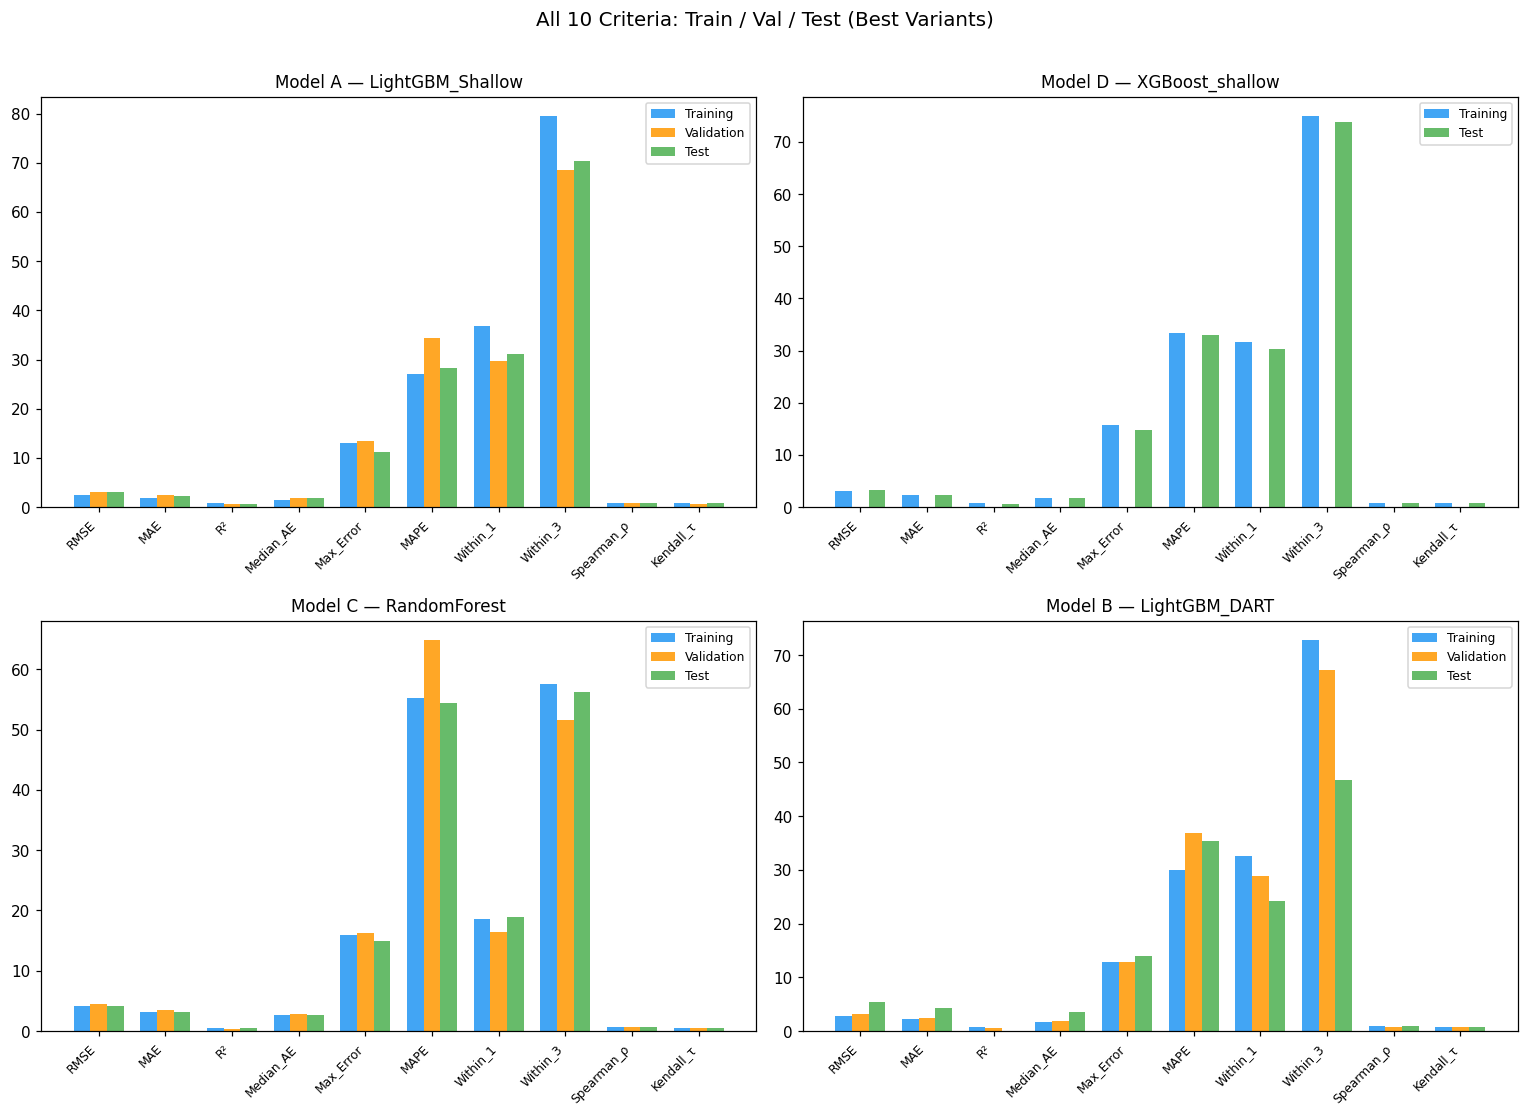

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

split_order = ["Training", "Validation", "Test"]
color_map = {"Training": "#2196F3", "Validation": "#FF9800", "Test": "#4CAF50"}

for idx, (model, variant) in enumerate(best_variants):
    if idx >= 4:
        break
    ax = axes[idx]
    subset = overfit_df[(overfit_df["Model"] == model) & (overfit_df["Variant"] == variant)]
    subset = subset.set_index("Split").reindex([s for s in split_order if s in subset["Split"].values])

    x = np.arange(len(CRITERIA_COLS))
    for i, split in enumerate(split_order):
        if split not in subset.index:
            continue
        vals = subset.loc[split, CRITERIA_COLS].values.astype(float)
        # Normalise to [0,1] for radar-like grouped bar
        ax.bar(x + i * 0.25, vals, 0.25, label=split, color=color_map[split], alpha=0.85)

    ax.set_xticks(x + 0.25)
    ax.set_xticklabels(CRITERIA_COLS, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"Model {model} — {variant}", fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle("All 10 Criteria: Train / Val / Test (Best Variants)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Head-to-Head: Best Models on Test Set

Grouped bar chart comparing the 4 model types side-by-side.

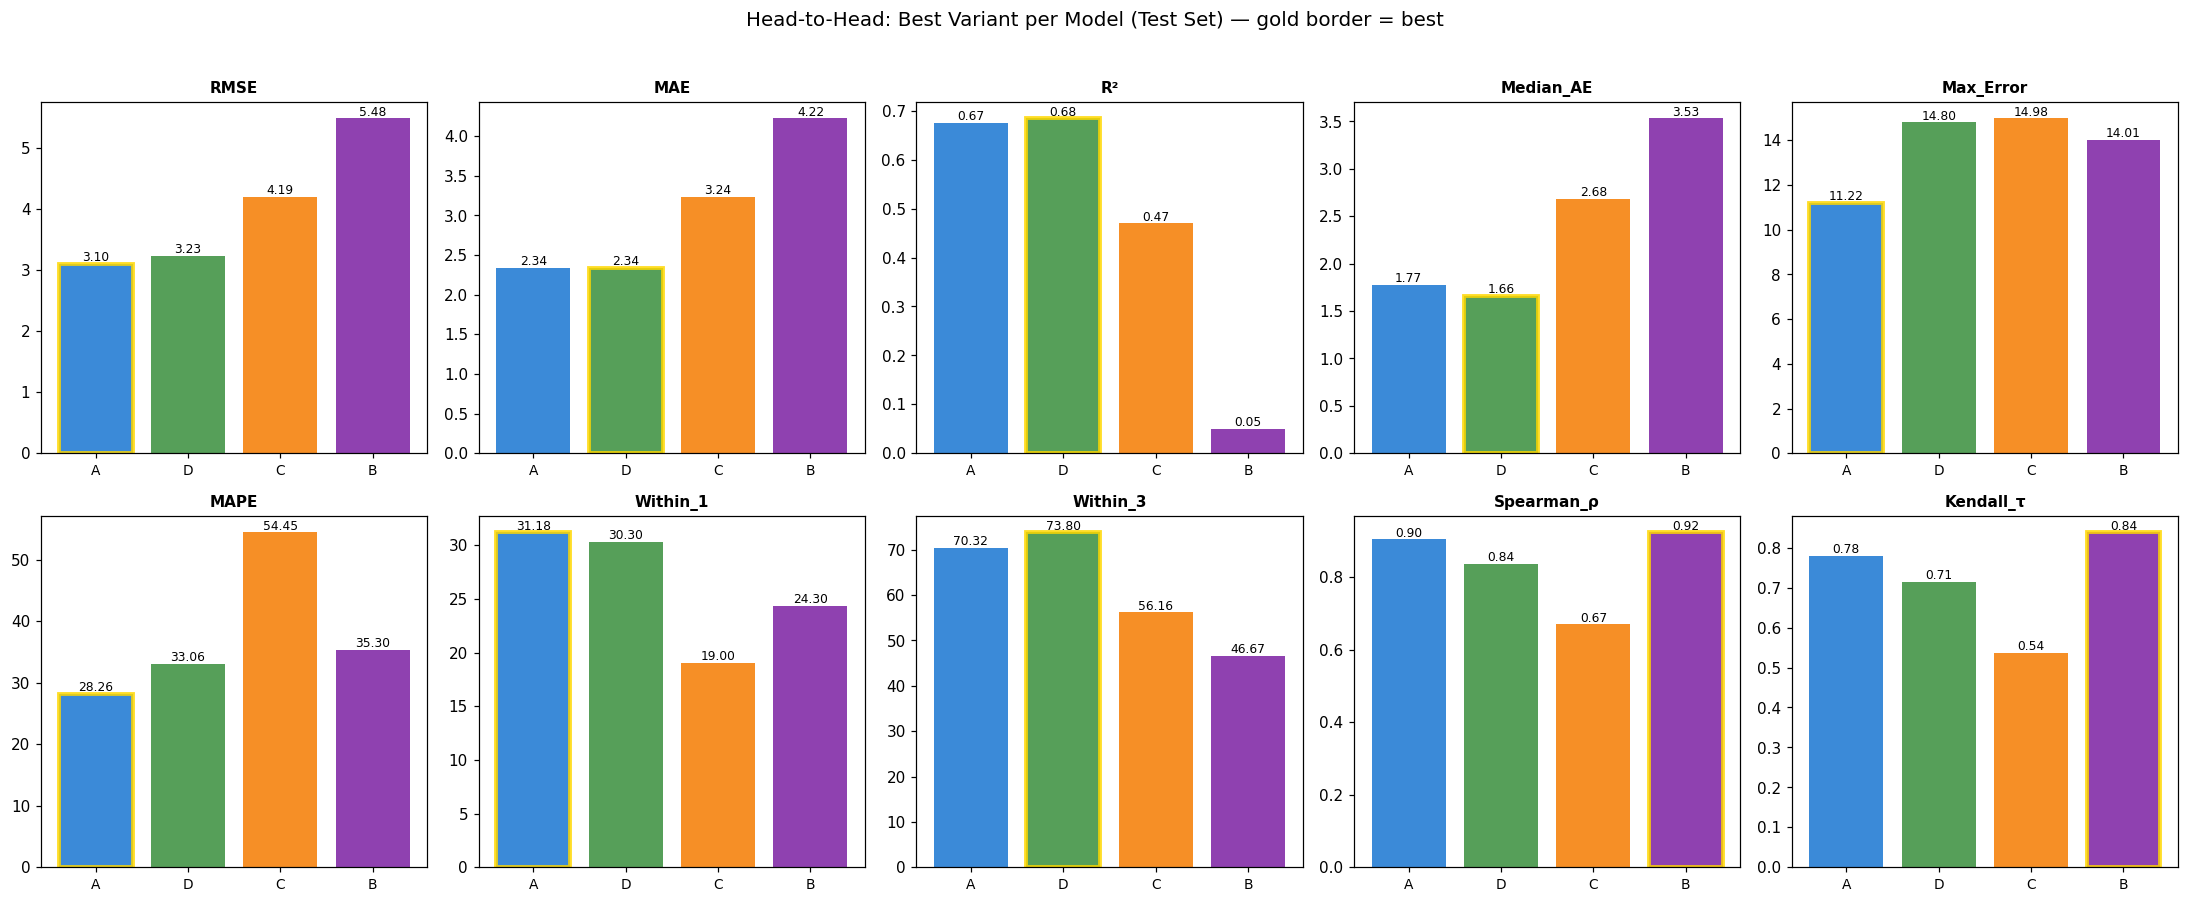

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, metric in enumerate(CRITERIA_COLS):
    ax = axes[i // 5, i % 5]
    models = best_test["Model"].values
    vals = best_test[metric].values.astype(float)
    colours = ["#1976D2", "#388E3C", "#F57C00", "#7B1FA2"][:len(models)]
    bars = ax.bar(models, vals, color=colours, alpha=0.85)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{v:.2f}", ha="center", va="bottom", fontsize=8)

    ax.set_title(metric, fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", labelsize=9)

    # Mark "good" direction
    lower_better = metric in ("RMSE", "MAE", "Median_AE", "Max_Error", "MAPE")
    best_val = min(vals) if lower_better else max(vals)
    best_idx_arr = np.where(vals == best_val)[0]
    for bi in best_idx_arr:
        bars[bi].set_edgecolor("gold")
        bars[bi].set_linewidth(2.5)

plt.suptitle("Head-to-Head: Best Variant per Model (Test Set) — gold border = best",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Per-Model Variant Rankings

Within each model type, how do the variants compare on the test set?

In [11]:
for model_type in sorted(test_df["Model"].unique()):
    subset = test_df[test_df["Model"] == model_type].sort_values("RMSE")
    print(f"\n{'='*70}")
    print(f"Model {model_type} — Test Set Rankings ({len(subset)} variants)")
    print(f"{'='*70}")
    print(subset[["Variant"] + CRITERIA_COLS].to_string(index=False))


Model A — Test Set Rankings (5 variants)
         Variant     RMSE      MAE       R²  Median_AE  Max_Error      MAPE  Within_1  Within_3  Spearman_ρ  Kendall_τ
LightGBM_Shallow 3.102836 2.341194 0.674314   1.774531  11.215151 28.257104 31.182796 70.322581    0.903709   0.778994
   LightGBM_Deep 3.102836 2.341194 0.674314   1.774531  11.215151 28.257105 31.182796 70.322581    0.903709   0.778994
        LightGBM 3.102891 2.341282 0.674302   1.774531  11.215151 28.257595 31.182796 70.322581    0.903709   0.778994
   LightGBM_GOSS 3.174224 2.396155 0.659155   1.791209  11.643212 28.334287 30.107527 69.892473    0.899583   0.772628
   LightGBM_DART 3.193074 2.384335 0.655095   1.723633  12.705898 27.909474 32.473118 68.387097    0.886632   0.759489

Model B — Test Set Rankings (5 variants)
         Variant     RMSE      MAE        R²  Median_AE  Max_Error      MAPE  Within_1  Within_3  Spearman_ρ  Kendall_τ
   LightGBM_DART 5.484942 4.224537  0.048888   3.532056  14.009719 35.300394 24.30

## 9. Ranking Quality Deep Dive

Spearman ρ and Kendall τ measure how well predicted positions preserve the true finishing order within each race. Values close to 1.0 mean the model ranks drivers correctly even if absolute positions are off.

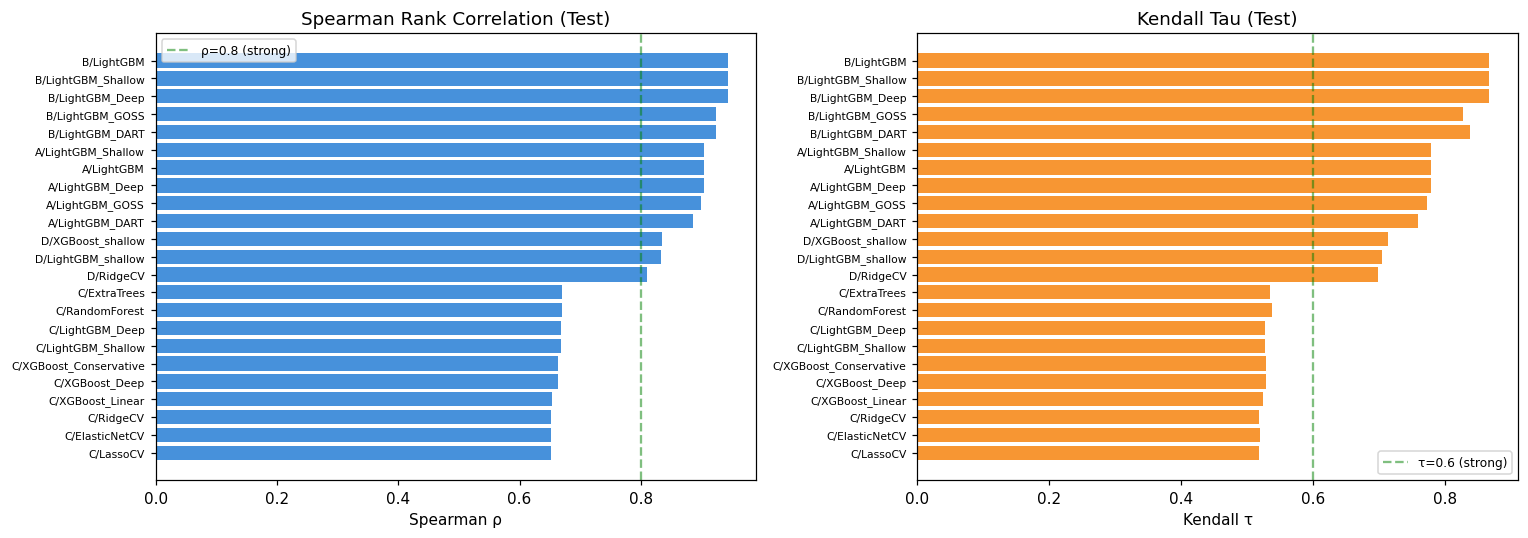

In [12]:
rank_cols = ["Model", "Variant", "Split", "Spearman_ρ", "Kendall_τ"]
rank_df = results_df[results_df["Split"] == "Test"][rank_cols].sort_values("Spearman_ρ", ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

labels = rank_df.apply(lambda r: f"{r['Model']}/{r['Variant']}", axis=1).values
x = np.arange(len(labels))

ax1.barh(x, rank_df["Spearman_ρ"].values, color="#1976D2", alpha=0.8)
ax1.set_yticks(x)
ax1.set_yticklabels(labels, fontsize=7)
ax1.set_xlabel("Spearman ρ")
ax1.set_title("Spearman Rank Correlation (Test)")
ax1.invert_yaxis()
ax1.axvline(x=0.8, color="green", linestyle="--", alpha=0.5, label="ρ=0.8 (strong)")
ax1.legend(fontsize=8)

ax2.barh(x, rank_df["Kendall_τ"].values, color="#F57C00", alpha=0.8)
ax2.set_yticks(x)
ax2.set_yticklabels(labels, fontsize=7)
ax2.set_xlabel("Kendall τ")
ax2.set_title("Kendall Tau (Test)")
ax2.invert_yaxis()
ax2.axvline(x=0.6, color="green", linestyle="--", alpha=0.5, label="τ=0.6 (strong)")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 10. Position Accuracy Breakdown

What percentage of predictions land exactly right, within 1, 2, or 3 positions?

In [13]:
accuracy_rows = []
for _, row in inventory[inventory["split"] == "Test"].iterrows():
    df = pd.read_parquet(row["path"])
    df = aggregate_laps_to_race(df)
    errs = np.abs(df["y_true"].values - df["y_pred"].values)
    accuracy_rows.append({
        "Model": row["model_type"], "Variant": row["variant"],
        "Exact": np.mean(errs < 0.5) * 100,
        "Within_1": np.mean(errs <= 1.0) * 100,
        "Within_2": np.mean(errs <= 2.0) * 100,
        "Within_3": np.mean(errs <= 3.0) * 100,
        "Within_5": np.mean(errs <= 5.0) * 100,
        ">5_off": np.mean(errs > 5.0) * 100,
    })

acc_df = pd.DataFrame(accuracy_rows).sort_values("Within_3", ascending=False)

# Show best variant per model
best_acc = acc_df.groupby("Model").first().reset_index().sort_values("Within_3", ascending=False)
print("Position accuracy (best variant per model, test set):\n")
print(best_acc.to_string(index=False, float_format="{:.1f}%".format))

Position accuracy (best variant per model, test set):

Model         Variant  Exact  Within_1  Within_2  Within_3  Within_5  >5_off
    D XGBoost_shallow  15.0%     30.3%     56.3%     73.8%     89.7%   10.3%
    A        LightGBM  18.3%     31.2%     55.3%     70.3%     89.5%   10.5%
    C    RandomForest   8.4%     19.0%     38.0%     56.2%     82.5%   17.5%
    B   LightGBM_DART  15.7%     24.3%     37.2%     46.7%     61.7%   38.3%


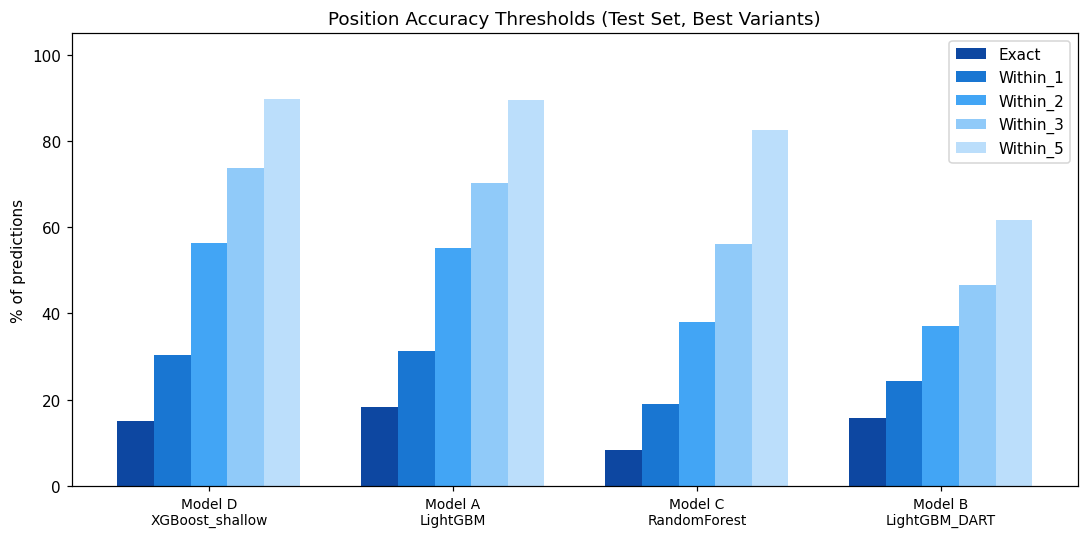

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
thresholds = ["Exact", "Within_1", "Within_2", "Within_3", "Within_5"]
colours = ["#0D47A1", "#1976D2", "#42A5F5", "#90CAF9", "#BBDEFB"]

x = np.arange(len(best_acc))
width = 0.15
for i, (thresh, col) in enumerate(zip(thresholds, colours)):
    ax.bar(x + i * width, best_acc[thresh].values, width, label=thresh, color=col)

ax.set_xticks(x + width * 2)
ax.set_xticklabels([f"Model {r['Model']}\n{r['Variant']}" for _, r in best_acc.iterrows()],
                   fontsize=9)
ax.set_ylabel("% of predictions")
ax.set_title("Position Accuracy Thresholds (Test Set, Best Variants)")
ax.legend()
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## Summary

In [15]:
print("=" * 70)
print("MODEL COMPARISON SUMMARY — 10 CRITERIA")
print("=" * 70)

print("\nBest variant per model (by test RMSE):")
for _, row in best_test.iterrows():
    print(f"  Model {row['Model']:2s}  {row['Variant']:25s}  "
          f"RMSE={row['RMSE']:.4f}  R²={row['R²']:.4f}  "
          f"Spearman={row['Spearman_ρ']:.4f}  Within-3={row['Within_3']:.1f}%")

overall_best = best_test.iloc[0]
print(f"\nOverall best: Model {overall_best['Model']} / {overall_best['Variant']}")
print(f"  RMSE={overall_best['RMSE']:.4f}, R²={overall_best['R²']:.4f}, "
      f"Within-3={overall_best['Within_3']:.1f}%, "
      f"Spearman ρ={overall_best['Spearman_ρ']:.4f}")

MODEL COMPARISON SUMMARY — 10 CRITERIA

Best variant per model (by test RMSE):
  Model A   LightGBM_Shallow           RMSE=3.1028  R²=0.6743  Spearman=0.9037  Within-3=70.3%
  Model D   XGBoost_shallow            RMSE=3.2340  R²=0.6842  Spearman=0.8351  Within-3=73.8%
  Model C   RandomForest               RMSE=4.1921  R²=0.4696  Spearman=0.6694  Within-3=56.2%
  Model B   LightGBM_DART              RMSE=5.4849  R²=0.0489  Spearman=0.9232  Within-3=46.7%

Overall best: Model A / LightGBM_Shallow
  RMSE=3.1028, R²=0.6743, Within-3=70.3%, Spearman ρ=0.9037
